In [1]:
import pandas as pd
dat=pd.read_csv("D:\Internship Report\carPrice.csv")

In [2]:
dat.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')

In [3]:
dat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [4]:
dat.isna().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [5]:
print(dat.dtypes)

Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type         object
Seller_Type       object
Transmission      object
Owner              int64
dtype: object


In [6]:
dat.head(12)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
5,vitara brezza,2018,9.25,9.83,2071,Diesel,Dealer,Manual,0
6,ciaz,2015,6.75,8.12,18796,Petrol,Dealer,Manual,0
7,s cross,2015,6.50,8.61,33429,Diesel,Dealer,Manual,0
8,ciaz,2016,8.75,8.89,20273,Diesel,Dealer,Manual,0
9,ciaz,2015,7.45,8.92,42367,Diesel,Dealer,Manual,0


In [7]:
dat.tail(5)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


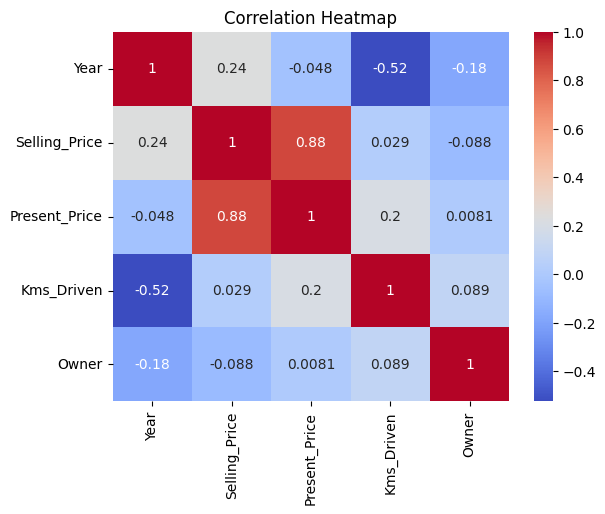

In [8]:
import seaborn as se
import matplotlib.pyplot as plt
se.heatmap(dat.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

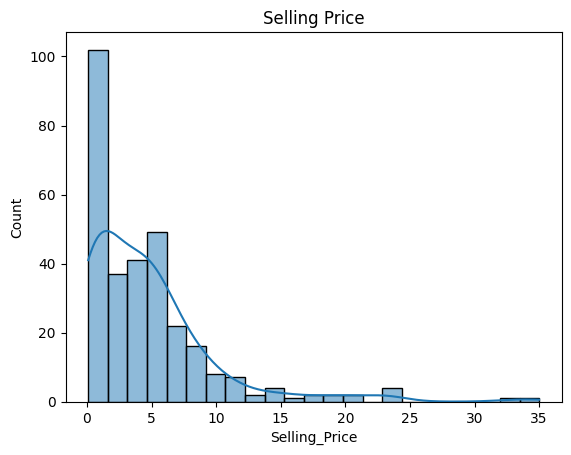

In [9]:
se.histplot(dat['Selling_Price'],kde=True)
plt.title('Selling Price')
plt.show()

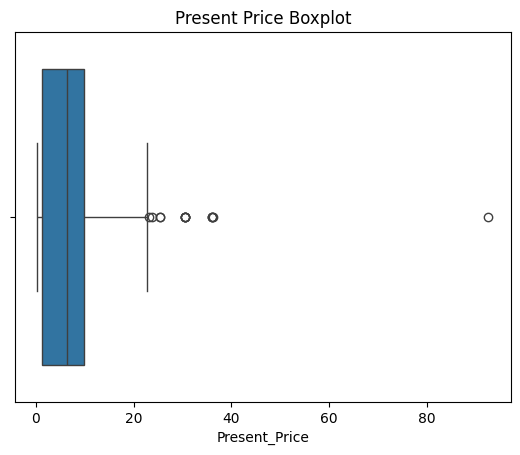

In [10]:
se.boxplot(x='Present_Price',data=dat)
plt.title('Present Price Boxplot')
plt.show()

In [11]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
dat['Fuel_Type_encoded']=le.fit_transform(dat['Fuel_Type'])
print(dat)

    Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0       ritz  2014           3.35           5.59       27000    Petrol   
1        sx4  2013           4.75           9.54       43000    Diesel   
2       ciaz  2017           7.25           9.85        6900    Petrol   
3    wagon r  2011           2.85           4.15        5200    Petrol   
4      swift  2014           4.60           6.87       42450    Diesel   
..       ...   ...            ...            ...         ...       ...   
296     city  2016           9.50          11.60       33988    Diesel   
297     brio  2015           4.00           5.90       60000    Petrol   
298     city  2009           3.35          11.00       87934    Petrol   
299     city  2017          11.50          12.50        9000    Diesel   
300     brio  2016           5.30           5.90        5464    Petrol   

    Seller_Type Transmission  Owner  Fuel_Type_encoded  
0        Dealer       Manual      0                  2

In [12]:
encoded_data=pd.get_dummies(dat,columns=['Seller_Type'])
print(encoded_data)

    Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0       ritz  2014           3.35           5.59       27000    Petrol   
1        sx4  2013           4.75           9.54       43000    Diesel   
2       ciaz  2017           7.25           9.85        6900    Petrol   
3    wagon r  2011           2.85           4.15        5200    Petrol   
4      swift  2014           4.60           6.87       42450    Diesel   
..       ...   ...            ...            ...         ...       ...   
296     city  2016           9.50          11.60       33988    Diesel   
297     brio  2015           4.00           5.90       60000    Petrol   
298     city  2009           3.35          11.00       87934    Petrol   
299     city  2017          11.50          12.50        9000    Diesel   
300     brio  2016           5.30           5.90        5464    Petrol   

    Transmission  Owner  Fuel_Type_encoded  Seller_Type_Dealer  \
0         Manual      0                  2   

In [13]:
dat.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner',
       'Fuel_Type_encoded'],
      dtype='object')

In [14]:
from sklearn.preprocessing import MinMaxScaler
scale=MinMaxScaler()
dat['Selling_Price_Scaled']=scale.fit_transform(dat[['Selling_Price']])
print(dat)

    Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0       ritz  2014           3.35           5.59       27000    Petrol   
1        sx4  2013           4.75           9.54       43000    Diesel   
2       ciaz  2017           7.25           9.85        6900    Petrol   
3    wagon r  2011           2.85           4.15        5200    Petrol   
4      swift  2014           4.60           6.87       42450    Diesel   
..       ...   ...            ...            ...         ...       ...   
296     city  2016           9.50          11.60       33988    Diesel   
297     brio  2015           4.00           5.90       60000    Petrol   
298     city  2009           3.35          11.00       87934    Petrol   
299     city  2017          11.50          12.50        9000    Diesel   
300     brio  2016           5.30           5.90        5464    Petrol   

    Seller_Type Transmission  Owner  Fuel_Type_encoded  Selling_Price_Scaled  
0        Dealer       Manual    

In [15]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
dat['Kms_Driven_Scaled']=scaler.fit_transform(dat[['Kms_Driven']])
print(dat)

    Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0       ritz  2014           3.35           5.59       27000    Petrol   
1        sx4  2013           4.75           9.54       43000    Diesel   
2       ciaz  2017           7.25           9.85        6900    Petrol   
3    wagon r  2011           2.85           4.15        5200    Petrol   
4      swift  2014           4.60           6.87       42450    Diesel   
..       ...   ...            ...            ...         ...       ...   
296     city  2016           9.50          11.60       33988    Diesel   
297     brio  2015           4.00           5.90       60000    Petrol   
298     city  2009           3.35          11.00       87934    Petrol   
299     city  2017          11.50          12.50        9000    Diesel   
300     brio  2016           5.30           5.90        5464    Petrol   

    Seller_Type Transmission  Owner  Fuel_Type_encoded  Selling_Price_Scaled  \
0        Dealer       Manual   

In [16]:
dat.head(25)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Fuel_Type_encoded,Selling_Price_Scaled,Kms_Driven_Scaled
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,2,0.093123,-0.256224
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,1,0.133238,0.155911
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,2,0.204871,-0.773969
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,2,0.078797,-0.817758
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,1,0.128940,0.141743
5,vitara brezza,2018,9.25,9.83,2071,Diesel,Dealer,Manual,0,1,0.262178,-0.898356
6,ciaz,2015,6.75,8.12,18796,Petrol,Dealer,Manual,0,2,0.190544,-0.467547
7,s cross,2015,6.50,8.61,33429,Diesel,Dealer,Manual,0,1,0.183381,-0.090623
8,ciaz,2016,8.75,8.89,20273,Diesel,Dealer,Manual,0,1,0.247851,-0.429501
9,ciaz,2015,7.45,8.92,42367,Diesel,Dealer,Manual,0,1,0.210602,0.139605


In [17]:
dat.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner',
       'Fuel_Type_encoded', 'Selling_Price_Scaled', 'Kms_Driven_Scaled'],
      dtype='object')

In [18]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
dat['Transmission_Encoded']=le.fit_transform(dat['Transmission'])
print(dat)

    Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0       ritz  2014           3.35           5.59       27000    Petrol   
1        sx4  2013           4.75           9.54       43000    Diesel   
2       ciaz  2017           7.25           9.85        6900    Petrol   
3    wagon r  2011           2.85           4.15        5200    Petrol   
4      swift  2014           4.60           6.87       42450    Diesel   
..       ...   ...            ...            ...         ...       ...   
296     city  2016           9.50          11.60       33988    Diesel   
297     brio  2015           4.00           5.90       60000    Petrol   
298     city  2009           3.35          11.00       87934    Petrol   
299     city  2017          11.50          12.50        9000    Diesel   
300     brio  2016           5.30           5.90        5464    Petrol   

    Seller_Type Transmission  Owner  Fuel_Type_encoded  Selling_Price_Scaled  \
0        Dealer       Manual   

In [19]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
dat['Car_Name_Encoded']=le.fit_transform(dat['Car_Name'])
print(dat)

    Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0       ritz  2014           3.35           5.59       27000    Petrol   
1        sx4  2013           4.75           9.54       43000    Diesel   
2       ciaz  2017           7.25           9.85        6900    Petrol   
3    wagon r  2011           2.85           4.15        5200    Petrol   
4      swift  2014           4.60           6.87       42450    Diesel   
..       ...   ...            ...            ...         ...       ...   
296     city  2016           9.50          11.60       33988    Diesel   
297     brio  2015           4.00           5.90       60000    Petrol   
298     city  2009           3.35          11.00       87934    Petrol   
299     city  2017          11.50          12.50        9000    Diesel   
300     brio  2016           5.30           5.90        5464    Petrol   

    Seller_Type Transmission  Owner  Fuel_Type_encoded  Selling_Price_Scaled  \
0        Dealer       Manual   

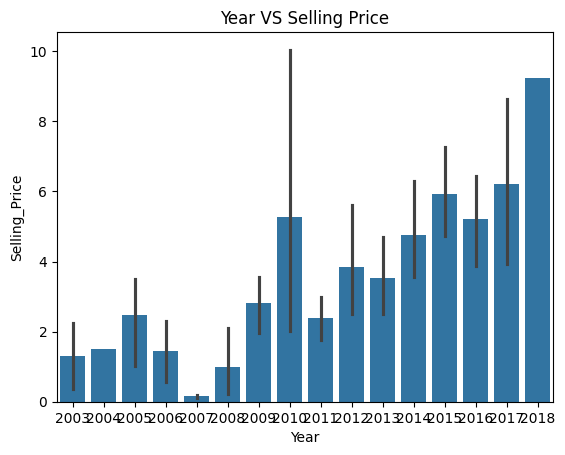

In [20]:
se.barplot(x='Year',y='Selling_Price',data=dat)
plt.title('Year VS Selling Price')
plt.show()

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
features=['Year', 'Selling_Price','Present_Price' , 'Kms_Driven','Fuel_Type_encoded','Owner','Transmission_Encoded']
target=['Car_Name_Encoded']
x=dat[features] 
y=dat[target]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [22]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [23]:
import numpy as np
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
y_pred=model.predict(x_test)
print("Linear Regression Results:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² Score:", r2_score(y_test, y_pred))


Linear Regression Results:
MAE: 16.48783699998341
MSE: 418.2001013878647
RMSE: 20.449941354142428
R² Score: 0.3151079952359547


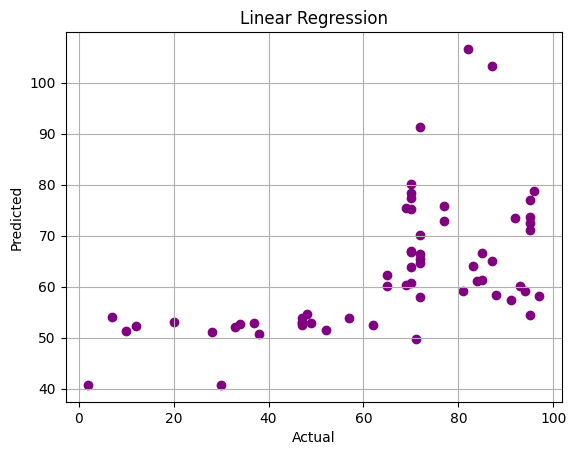

In [24]:
plt.scatter(y_test, y_pred, color='purple')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Linear Regression')
plt.grid(True)
plt.show()


In [25]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Step 2: Load dataset (sample dataset - replace with your own)


# Step 4: Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Step 5: Train the Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Step 6: Make predictions
y_pred = model.predict(X_test)

# Step 7: Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Step 8: Print evaluation results
print("Random Forest Regressor Performance:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}") 


Random Forest Regressor Performance:
Mean Absolute Error (MAE): 6.96
Root Mean Squared Error (RMSE): 10.49
R² Score: 0.82


c:\Users\jenif\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


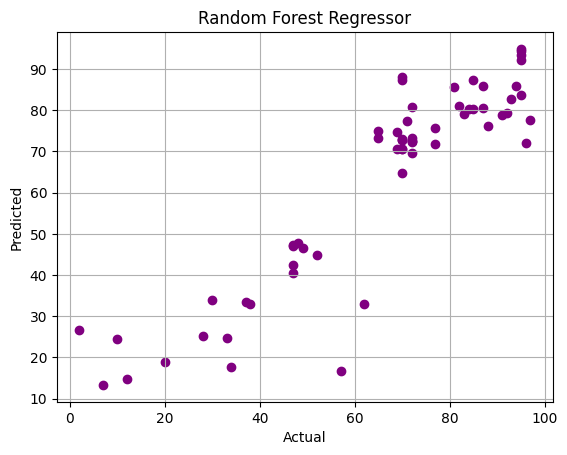

In [26]:
plt.scatter(y_test, y_pred, color='purple')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Random Forest Regressor')
plt.grid(True)
plt.show()

In [27]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb


# Step 4: Split dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Step 5: Initialize and train XGBoost Regressor
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', 
                             n_estimators=100, 
                             learning_rate=0.1, 
                             max_depth=5, 
                             random_state=42)
xgb_model.fit(X_train, y_train)

# Step 6: Predict on test data
y_pred = xgb_model.predict(X_test)

# Step 7: Evaluate model performance
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("XGBoost Regressor Results:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")


XGBoost Regressor Results:
Mean Absolute Error (MAE): 6.56
Root Mean Squared Error (RMSE): 9.74
R² Score: 0.84


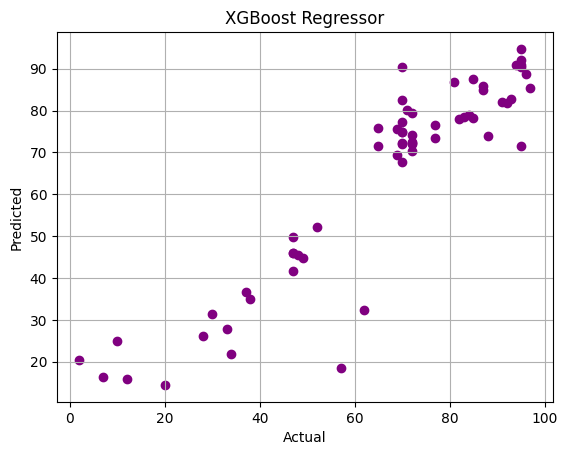

In [28]:
plt.scatter(y_test, y_pred, color='purple')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('XGBoost Regressor')
plt.grid(True)
plt.show()

In [29]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt


# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Initialize and train the Decision Tree Regressor
tree = DecisionTreeRegressor(max_depth=3, random_state=42)
tree.fit(X_train, y_train)

# Make predictions
y_pred = tree.predict(X_test)

# Evaluate model performance
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("Decision Tree Regressor Results:")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

Decision Tree Regressor Results:
MAE: 9.8481
RMSE: 12.1206
R² Score: 0.7594


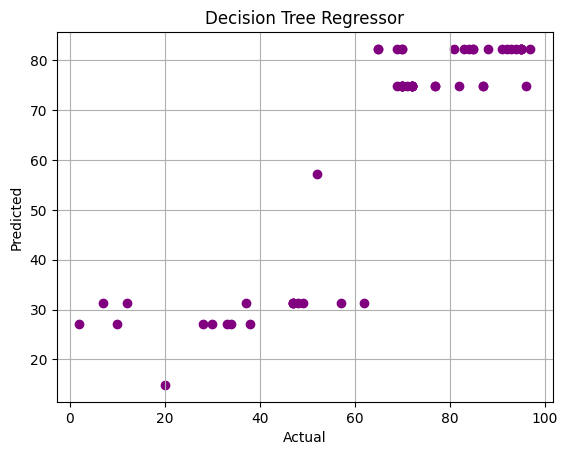

In [30]:
plt.scatter(y_test, y_pred, color='purple')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Decision Tree Regressor')
plt.grid(True)
plt.show()